# FarmTech Solutions — Fase 5: Machine Learning

**Nome:** 
**RM:** 
**Data:** 

In [1]:
import pandas as pd

---
# Etapa A — Análise Exploratória de Dados (EDA)

## A1 — Carregar o CSV

In [2]:
df = pd.read_csv ("../data/crop_yield.csv")
df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 6 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Crop                                  156 non-null    str    
 1   Precipitation (mm day-1)              156 non-null    float64
 2   Specific Humidity at 2 Meters (g/kg)  156 non-null    float64
 3   Relative Humidity at 2 Meters (%)     156 non-null    float64
 4   Temperature at 2 Meters (C)           156 non-null    float64
 5   Yield                                 156 non-null    int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 7.4 KB


,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
count,156.000000,156.000000,156.000000,156.00000,156.000000
mean,2486.498974,18.203077,84.737692,26.18359,56153.096154
std,289.457914,0.293923,0.996226,0.26105,70421.958897
min,1934.620000,17.540000,82.110000,25.56000,5249.000000
25%,2302.990000,18.030000,84.120000,26.02000,8327.750000
50%,2424.550000,18.270000,84.850000,26.13000,18871.000000
75%,2718.080000,18.400000,85.510000,26.30000,67518.750000
max,3085.790000,18.700000,86.100000,26.81000,203399.000000


## A2 — Checar Dados Faltantes

In [3]:
print(df.isnull().sum())
print(f'\nDuplicatas: {df.duplicated().sum()}')

Crop                                    0
Precipitation (mm day-1)                0
Specific Humidity at 2 Meters (g/kg)    0
Relative Humidity at 2 Meters (%)       0
Temperature at 2 Meters (C)             0
Yield                                   0
dtype: int64

Duplicatas: 0


## A3 — Analisar Distribuições

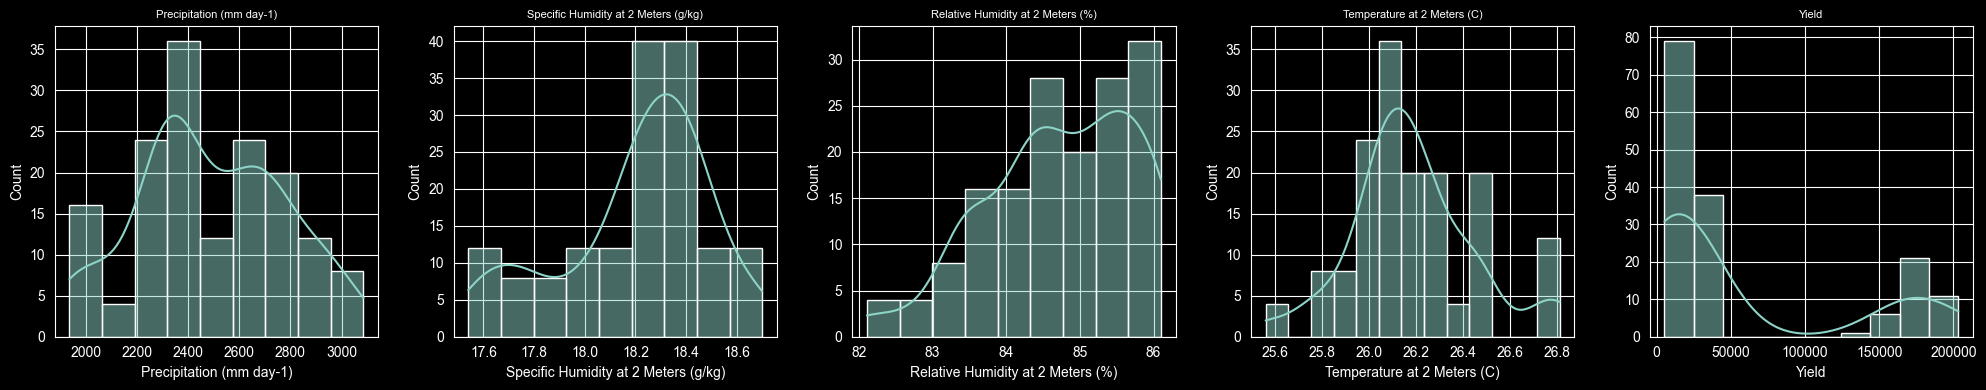

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

colunas = ['Precipitation (mm day-1)', 'Specific Humidity at 2 Meters (g/kg)',
           'Relative Humidity at 2 Meters (%)', 'Temperature at 2 Meters (C)', 'Yield']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, col in zip(axes, colunas):
    sns.histplot(df[col], ax=ax, kde=True)
    ax.set_title(col, fontsize=8)
plt.tight_layout()
plt.show()

## A4 — Ver Correlações

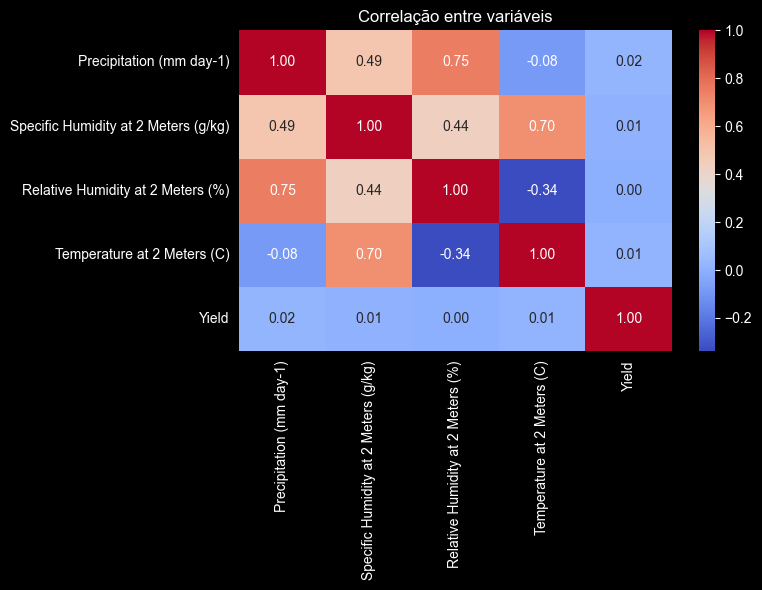

In [5]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[colunas].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlação entre variáveis')
plt.tight_layout()
plt.show()

## A5 — Visualizar por Cultura

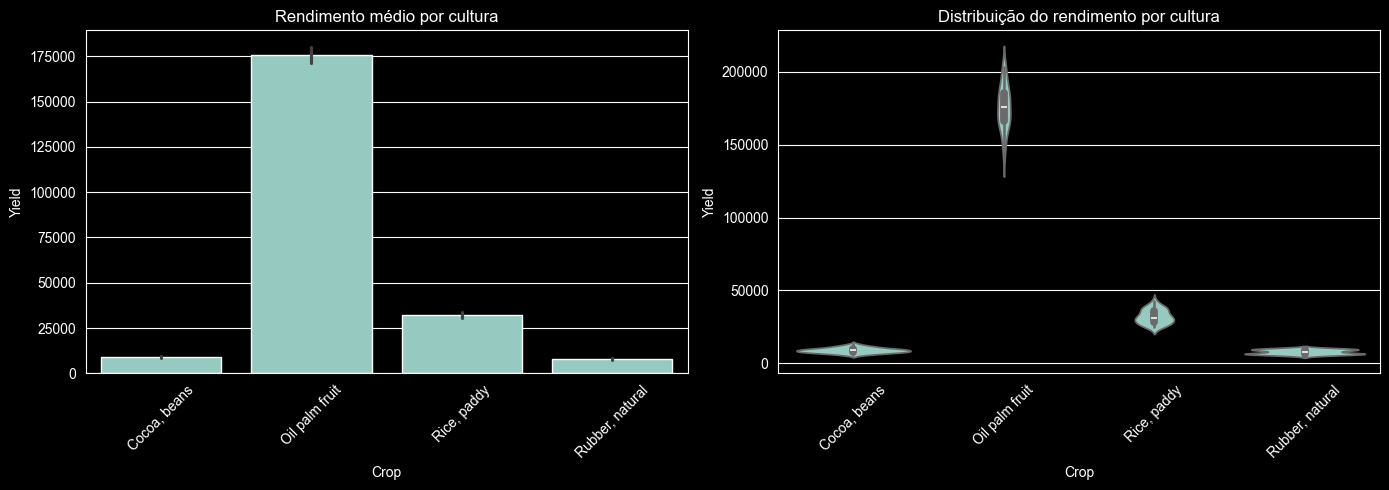

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df, x='Crop', y='Yield', ax=axes[0])
axes[0].set_title('Rendimento médio por cultura')
axes[0].tick_params(axis='x', rotation=45)

sns.violinplot(data=df, x='Crop', y='Yield', ax=axes[1])
axes[1].set_title('Distribuição do rendimento por cultura')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

---
# Etapa B — Clusterização

## B1 — Preparar os Dados

In [7]:
from sklearn.preprocessing import StandardScaler

features = ['Precipitation (mm day-1)', 'Specific Humidity at 2 Meters (g/kg)',
            'Relative Humidity at 2 Meters (%)', 'Temperature at 2 Meters (C)', 'Yield']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

print("Shape após normalização:", X_scaled.shape)
print("Média (deve ser ~0):", X_scaled.mean(axis=0).round(2))
print("Desvio padrão (deve ser ~1):", X_scaled.std(axis=0).round(2))

Shape após normalização: (156, 5)
Média (deve ser ~0): [ 0. -0.  0.  0. -0.]
Desvio padrão (deve ser ~1): [1. 1. 1. 1. 1.]


## B2 — Escolher Nº de Clusters

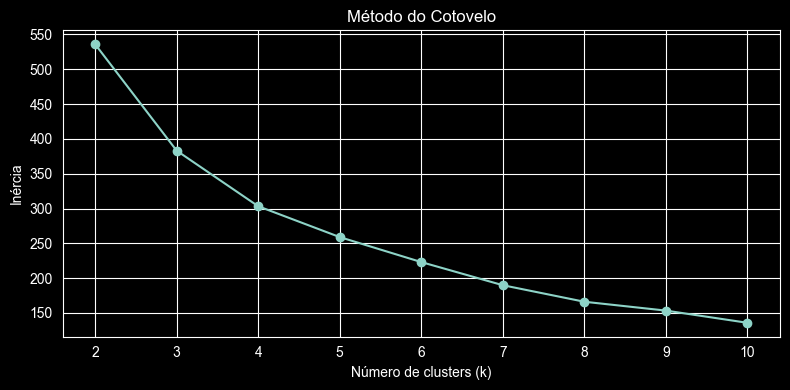

In [8]:
from sklearn.cluster import KMeans

inertias = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, marker='o')
plt.title('Método do Cotovelo')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inércia')
plt.tight_layout()
plt.show()

## B3 — Aplicar K-Means

In [9]:
k_otimo = 4
kmeans = KMeans(n_clusters=k_otimo, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print("Amostras por cluster:")
print(df['Cluster'].value_counts().sort_index())

Amostras por cluster:
Cluster
0    26
1    36
2    51
3    43
Name: count, dtype: int64


## B4 — Interpretar Clusters

In [10]:
print("\nCaracterísticas médias por cluster:")
print(df.groupby('Cluster')[features].mean().round(2))

print("\nCulturas por cluster:")
print(df.groupby('Cluster')['Crop'].value_counts())


Características médias por cluster:
         Precipitation (mm day-1)  Specific Humidity at 2 Meters (g/kg)  \
Cluster                                                                   
0                         2610.11                                 18.32   
1                         2353.61                                 18.41   
2                         2733.52                                 18.34   
3                         2230.03                                 17.80   

         Relative Humidity at 2 Meters (%)  Temperature at 2 Meters (C)  \
Cluster                                                                   
0                                    85.20                        26.20   
1                                    84.11                        26.51   
2                                    85.65                        26.12   
3                                    83.90                        25.98   

             Yield  
Cluster             
0        178310.15 

## B5 — Detectar Outliers

Silhouette Score: 0.363

Outliers detectados: 7
                Crop   Yield  Cluster
3       Cocoa, beans    9321        3
40    Oil palm fruit  201436        3
42    Oil palm fruit  181826        3
74    Oil palm fruit  172601        1
77    Oil palm fruit  189896        1
81       Rice, paddy   25187        3
120  Rubber, natural    9718        3


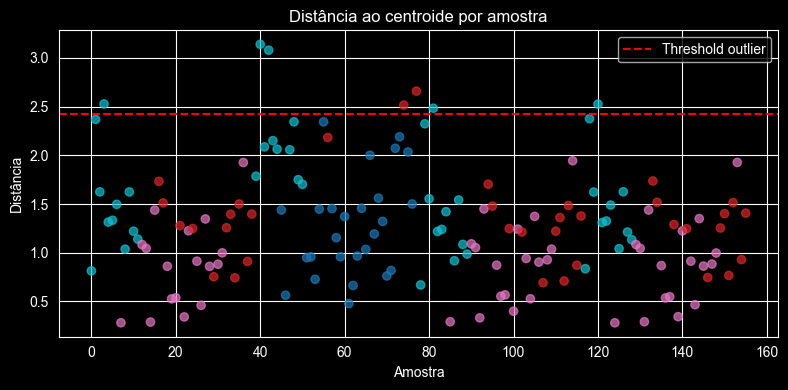

In [11]:
from sklearn.metrics import silhouette_score
import numpy as np

# Silhouette score geral
score = silhouette_score(X_scaled, df['Cluster'])
print(f"Silhouette Score: {score:.3f}")

# Detectar outliers: pontos com distância muito alta ao centroide do cluster
distances = kmeans.transform(X_scaled)
min_dist = distances[np.arange(len(df)), df['Cluster']]
threshold = min_dist.mean() + 2 * min_dist.std()
outliers = df[min_dist > threshold]

print(f"\nOutliers detectados: {len(outliers)}")
print(outliers[['Crop', 'Yield', 'Cluster']])

# Visualizar
plt.figure(figsize=(8, 4))
plt.scatter(range(len(df)), min_dist, c=df['Cluster'], cmap='tab10', alpha=0.7)
plt.axhline(threshold, color='red', linestyle='--', label='Threshold outlier')
plt.title('Distância ao centroide por amostra')
plt.xlabel('Amostra')
plt.ylabel('Distância')
plt.legend()
plt.tight_layout()
plt.show()

---
# Etapa C — Modelos Preditivos

## C1 — Separar Treino/Teste

## C2 — Normalizar Features

## C3 — Treinar 5 Modelos

## C4 — Avaliar com Métricas

## C5 — Comparar e Justificar

## C6 — Exportar Modelos